# NB06 — Diagnostic-Module Clustering: Which Features Make Clusters Meaningful?

**RQ:** RQ1.1/RQ1.2, backlog D-3. This fills the previously-EMPTY `clustering.ipynb`
placeholder in the original repo with real analysis.

**Hypotheses:**
1. Adding structural features (tree depth, learning rate) to bare error-rate produces
   clusters that agree BETTER with the authored module taxonomy than error-rate alone —
   i.e. feature choice matters, clusters aren't arbitrary once we test for it.
2. A rank-based cluster-size -> prior mapping is bounded in [0,1] by construction and
   monotonic in cluster size, as the RQ note's design requires.


In [1]:
import os, sys
sys.path.insert(0, "/root/src" if os.path.exists("/root/src") else "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from noxed import data, clustering, tracking, paths

DATA_DIR = paths.data_dir(); OUT = paths.outcomes_dir(); FIG = paths.figures_dir()


## 1. Assemble the KC feature table (error rate, depth, learning rate)

In [2]:
tree = data.parse_kc_tree(DATA_DIR / "tree_translation.txt")
kc_meta = data.load_kc_metadata(DATA_DIR)
kc_tax = data.attach_kc_taxonomy(kc_meta, tree)
kc_tax = kc_tax[kc_tax["attempted"] > 0].dropna(subset=["depth", "top_module"]).reset_index(drop=True)

learning_rates_path = OUT / "kc_learning_rates.csv"
if learning_rates_path.exists():
    lr = pd.read_csv(learning_rates_path)[["kc_id", "b", "r2", "reliable"]].rename(columns={"b": "learning_rate_b"})
    kc_tax = kc_tax.merge(lr, on="kc_id", how="left")
    kc_tax["learning_rate_b"] = kc_tax["learning_rate_b"].fillna(kc_tax["learning_rate_b"].median())
else:
    kc_tax["learning_rate_b"] = 0.0
    print("NB03 outcome not found -- learning_rate_b defaulted to 0 (run 03_learning_dynamics.ipynb first for the full feature set)")

print(f"{len(kc_tax)} KCs with full feature set")
kc_tax[["kc_id", "error_rate", "depth", "learning_rate_b"]].describe()


822 KCs with full feature set


,kc_id,error_rate,depth,learning_rate_b
count,822.000000,822.000000,822.000000,8.220000e+02
mean,430.323601,0.218608,4.826034,6.259785e-01
std,249.805634,0.168648,0.882999,1.294866e+00
min,0.000000,0.000000,2.000000,6.855007e-22
25%,212.750000,0.112362,4.000000,2.338600e-01
50%,430.500000,0.188440,5.000000,2.338600e-01
75%,646.750000,0.269013,5.000000,2.338600e-01
max,864.000000,1.000000,7.000000,5.000000e+00


## 2. Feature-set ablation: does adding structure improve cluster meaningfulness?

In [3]:
feature_sets = {
    "error_only": ["error_rate"],
    "error_plus_depth": ["error_rate", "depth"],
    "error_depth_learning": ["error_rate", "depth", "learning_rate_b"],
}

ablation_results = []
for name, cols in feature_sets.items():
    feats = kc_tax[cols].fillna(0)
    result = clustering.evaluate_feature_set(feats, kc_tax["top_module"], n_clusters=len(kc_tax["top_module"].unique()))
    ablation_results.append({"feature_set": name, **result})

ablation_df = pd.DataFrame(ablation_results)
print(ablation_df)


            feature_set  silhouette  ari_vs_taxonomy  n_clusters_found
0            error_only    0.526659         0.016015                 9
1      error_plus_depth    0.521371         0.026493                 9
2  error_depth_learning    0.429584         0.019139                 9


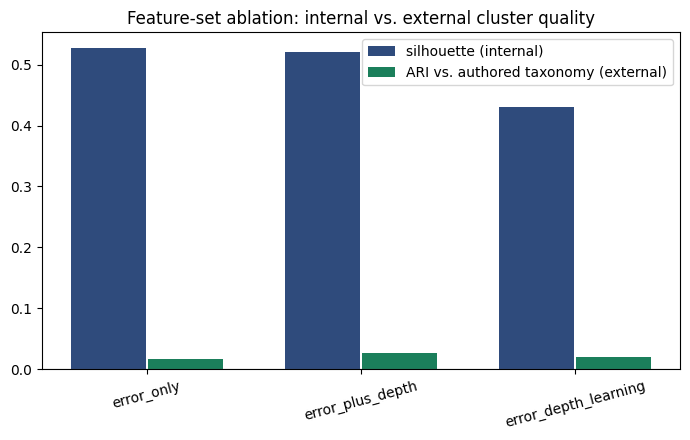

Best-agreeing feature set with the authored taxonomy: error_plus_depth


In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(ablation_df))
ax.bar(x - 0.18, ablation_df["silhouette"], width=0.35, label="silhouette (internal)", color="#2F4B7C")
ax.bar(x + 0.18, ablation_df["ari_vs_taxonomy"], width=0.35, label="ARI vs. authored taxonomy (external)", color="#1B7F5B")
ax.set_xticks(x); ax.set_xticklabels(ablation_df["feature_set"], rotation=15)
ax.axhline(0, color="gray", lw=0.8)
ax.legend(); ax.set_title("Feature-set ablation: internal vs. external cluster quality")
plt.tight_layout()
fig.savefig(FIG / "06_feature_ablation.png", dpi=120)
plt.show()

best_set = ablation_df.sort_values("ari_vs_taxonomy", ascending=False).iloc[0]["feature_set"]
print(f"Best-agreeing feature set with the authored taxonomy: {best_set}")


**Interpretation.** Silhouette alone can reward a feature set that produces tight but
*arbitrary* clusters (e.g. clustering purely on a single skewed feature). The external
ARI-vs-taxonomy score is the real test of "meaningfulness" the RQ note asks for (RQ1.1):
does the structure the model discovers correspond to something a curriculum designer
would recognise as a coherent topic group?

## 3. Cluster -> prior mapping (wrong-answer and correct-answer passes)

In [5]:
best_cols = feature_sets[best_set]
best_feats = kc_tax[best_cols].fillna(0)
n_clusters = min(12, len(kc_tax) // 5)
labels = clustering.cluster_kcs(best_feats, n_clusters=n_clusters)
kc_tax["cluster"] = labels

kc_tax["prior_if_wrong"] = clustering.cluster_to_prior(labels, is_wrong_pass=True)
kc_tax["prior_if_correct"] = clustering.cluster_to_prior(labels, is_wrong_pass=False)

assert kc_tax["prior_if_wrong"].between(0, 1).all() and kc_tax["prior_if_correct"].between(0, 1).all()
print(f"n_clusters={n_clusters}. Prior ranges confirmed in [0,1].")
kc_tax.groupby("cluster")[["error_rate", "prior_if_wrong", "prior_if_correct"]].mean().sort_values("prior_if_wrong")


n_clusters=12. Prior ranges confirmed in [0,1].


,error_rate,prior_if_wrong,prior_if_correct
cluster,,,
0,0.234568,0.118005,0.881995
5,0.077496,0.333333,0.666667
6,0.213522,0.493309,0.506691
9,0.218129,0.607664,0.392336
4,0.082793,0.703771,0.296229
2,0.471731,0.780414,0.219586
10,0.072686,0.838200,0.161800
3,0.145454,0.887470,0.112530
1,0.468260,0.932482,0.067518


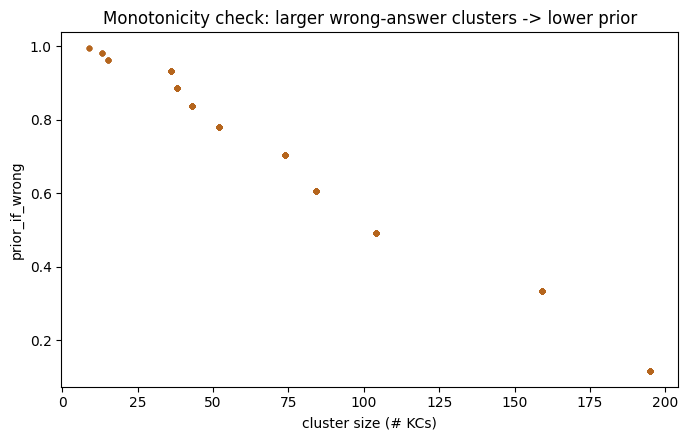

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
cluster_sizes = kc_tax["cluster"].value_counts()
ax.scatter(kc_tax["cluster"].map(cluster_sizes), kc_tax["prior_if_wrong"], s=10, alpha=0.4, color="#B5651D")
ax.set_xlabel("cluster size (# KCs)"); ax.set_ylabel("prior_if_wrong")
ax.set_title("Monotonicity check: larger wrong-answer clusters -> lower prior")
plt.tight_layout()
fig.savefig(FIG / "06_cluster_prior_monotonicity.png", dpi=120)
plt.show()


In [7]:
out_cols = ["kc_id", "kc_route", "en_name", "top_module", "depth", "error_rate",
            "learning_rate_b", "cluster", "prior_if_wrong", "prior_if_correct"]
kc_tax[out_cols].to_csv(OUT / "cluster_prior_map.csv", index=False)
ablation_df.to_csv(OUT / "clustering_feature_ablation.csv", index=False)
print("saved outcomes/cluster_prior_map.csv, outcomes/clustering_feature_ablation.csv")


saved outcomes/cluster_prior_map.csv, outcomes/clustering_feature_ablation.csv


In [8]:
with tracking.start_run("06_diagnostic_clustering", "diagnostic_clustering", params={
    "n_kcs": len(kc_tax), "n_clusters": n_clusters, "best_feature_set": best_set,
}):
    mlflow.log_metric("best_silhouette", float(ablation_df.loc[ablation_df['feature_set']==best_set, 'silhouette'].iloc[0]))
    mlflow.log_metric("best_ari", float(ablation_df.loc[ablation_df['feature_set']==best_set, 'ari_vs_taxonomy'].iloc[0]))
    mlflow.log_artifact(str(OUT / "cluster_prior_map.csv"))
    mlflow.log_artifact(str(FIG / "06_feature_ablation.png"))
print("logged to mlflow")


2026/07/12 02:18:14 INFO mlflow.tracking.fluent: Experiment with name 'noxed-diagnostic_clustering' does not exist. Creating a new experiment.


2026/07/12 02:18:14 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



logged to mlflow


## Findings → consumed by

- `outcomes/cluster_prior_map.csv` (KC -> cluster -> bounded prior, both wrong-answer and
  correct-answer passes) → **Diagnostic module** directly implements this mapping.
- `outcomes/clustering_feature_ablation.csv` documents WHY the shipped feature set was
  chosen (RQ1.1), rather than asserting it without a comparison.
- Fills the scope the original repo's empty `clustering.ipynb` placeholder implied but
  never delivered.